# INTERPOLATE ERA5, COMPUTE VSD

In [4]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature


import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

# CHOOSE

In [5]:
# TO CHOOSE 
drifters_sources = 'all_med_variational_10min_v0.nc'
spectral_decomp = True
dt = '12h' #'nearestswath'
if spectral_decomp == True : drifters_sources = 'spectral_decomp_'+ drifters_sources
colocs_sources = f'{dt}_'+drifters_sources

_______
# Data

In [10]:
if spectral_decomp == True : drifters_sources = 'spectral_decomp_'+ drifters_sources
df0 = pd.read_csv(os.path.join(zarr_dir,'wind', 'era5_'+colocs_sources.replace('.nc', '')+'.csv'))

In [12]:
df0.columns

Index(['row_number', 'u10', 'v10', 't2m', 'ewss', 'iews', 'inss', 'msl',
       'nsss', 'sst', 'ssr', 'ssrc', 'str', 'strc', 'sp', 'lgws', 'zust',
       'lsm', 'mwd', 'tauoc', 'mgws', 'pp1d', 'swh', 'shts', 'ust', 'vst',
       'mwp', 'f', 'ue_agesc_z0', 've_agesc_z0', 'utauz_agesc_z0',
       'vtauz_agesc_z0', 'us_agesc_z0', 'vs_agesc_z0', 'ues_agesc_z0',
       'ves_agesc_z0', 'us0_agesc_z0', 'vs0_agesc_z0', 'ua_agesc_z0',
       'va_agesc_z0', 'uw_agesc_z0', 'vw_agesc_z0', 'ustokes_agesc_z0',
       'vstokes_agesc_z0', 'vsde_agesc_z0', 'vsdn_agesc_z0', 'ue_rioold_z0',
       've_rioold_z0', 'ue_rio_z0', 've_rio_z0', 'vsde_rio_z0', 'vsdn_rio_z0',
       'vsde_rioold_z0', 'vsdn_rioold_z0', 'Ue_agesc_z0', 'Utauz_agesc_z0',
       'Us_agesc_z0', 'Ues_agesc_z0', 'Ue_rio_z0', 'Ue_rioold_z0',
       'Ua_agesc_z0', 'Uw_agesc_z0', 'U10', 'ue_agesc_z15', 've_agesc_z15',
       'utauz_agesc_z15', 'vtauz_agesc_z15', 'us_agesc_z15', 'vs_agesc_z15',
       'ues_agesc_z15', 'ves_agesc_z15', 'us0_

____________
# Some plots

In [11]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    
    da.plot(ax=ax, add_colorbar=False)
    #da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_96548/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_96548/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_96548/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_96548/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with 

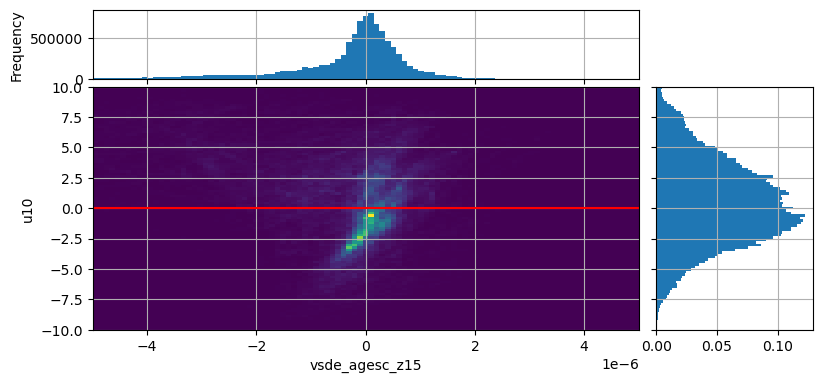

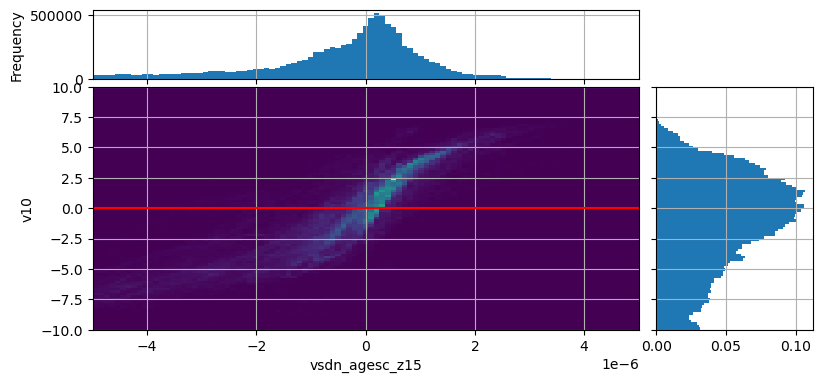

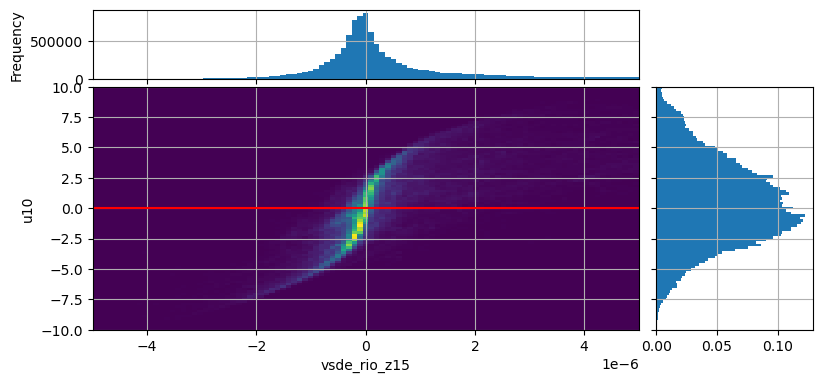

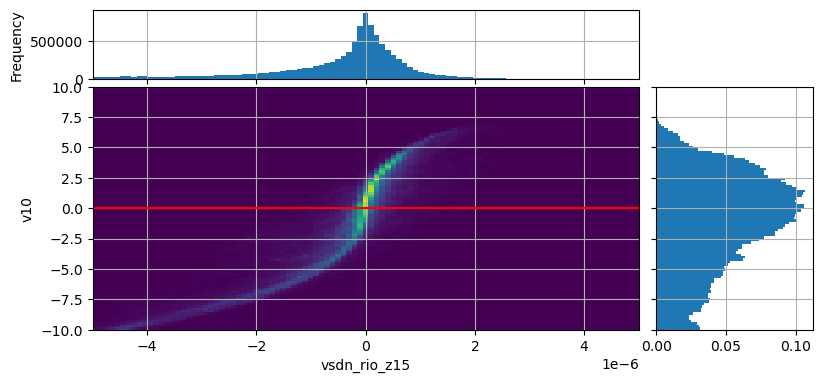

In [13]:
binx = np.linspace(-5e-6, 5e-6, 100)
biny = np.linspace(-10, 10, 100)

plot_join_pdfs(ds=df0, x='vsde_agesc_z15',y='u10',  binx=binx, biny=biny)
plot_join_pdfs(ds=df0, x='vsdn_agesc_z15',y='v10',  binx=binx, biny=biny)

plot_join_pdfs(ds=df0, x='vsde_rio_z15',y='u10',  binx=binx, biny=biny)
plot_join_pdfs(ds=df0, x='vsdn_rio_z15',y='v10',  binx=binx, biny=biny)